# 16B — AIA + SHARP Intermediate Fusion Training

**Purpose.** Train the first true multimodal fusion model:

\[
	ext{AIA image embedding} + 	ext{SHARP magnetic temporal embedding} ightarrow 	ext{48h M/X flare classifier}
\]

This notebook is designed for the **GPU VM**.

## Scientific guardrails

- Dataset scope: **Solar Cycle 24 only**, 2010–2015 folds.
- Interpretation: **within-cycle chronological/regime robustness**, not Cycle 24 → Cycle 25 generalisation.
- Official label: `label_48h_final` / `official_label_48h_final`.
- Embedded `.npz` labels are ignored.
- GOES/XRS input features are **not** used.
- SHARP temporal features are past-only relative to each AIA issue time.
- AIA augmentation: no random flips, rotations, or crops.
- Threshold selection: validation TSS only, then apply unchanged to held-out test year.

## Recommended run order

Start with one sanity fold:

`RUN_FOLDS = ["fusion_test_2015"]`

Then, after checking outputs, run:

`RUN_FOLDS = ["test_2013", "test_2014", "test_2015"]`


In [1]:
from pathlib import Path
import os, re, json, time, math, random, warnings
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / ".git").exists() and (p / "training").exists():
            return p
    for p in candidates:
        if (p / "training").exists() and (p / "results").exists():
            return p
    raise RuntimeError("Could not find project root. Run from inside the solar-flare-aia-training repo.")

ROOT = find_project_root()
TRAINING_DIR = ROOT / "training"
FUSION_DIR = TRAINING_DIR / "fusion_manifests"
METRICS_DIR = ROOT / "results" / "metrics"
FIG_DIR = ROOT / "results" / "figures"
MODEL_DIR = ROOT / "results" / "models"
PRED_DIR = ROOT / "results" / "predictions"

for d in [METRICS_DIR, FIG_DIR, MODEL_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Generated:", datetime.now().isoformat(timespec="seconds"))
print("CWD:", Path.cwd())


ROOT: /home/abmoses2000/solar_flare_aia
Generated: 2026-08-03T22:22:44
CWD: /home/abmoses2000/solar_flare_aia/notebooks/training


## 1. Configuration

In [2]:
# =========================
# USER CONFIGURATION
# =========================

# Start with test_2015 only to avoid wasting GPU time.
# After sanity-checking, change to ["fusion_test_2013", "fusion_test_2014", "fusion_test_2015"].
RUN_FOLDS = ["fusion_test_2015"]

# First official fusion setup.
FUSION_EXPERIMENT_NAME = "aia_resnet18_sharp24h_intermediate_fusion_cycle24"

# Image/model settings.
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 2
PATIENCE = 2
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.35
AIA_EMBED_DIM = 256
SHARP_EMBED_DIM = 64
FUSION_HIDDEN_DIM = 128

# Runtime controls.
NUM_WORKERS = 2
PIN_MEMORY = True
RANDOM_STATE = 42

# Data loading.
# The notebook will try multiple local cache roots automatically.
# Add/adjust paths below only if needed.
LOCAL_AIA_CACHE_CANDIDATES = [
    ROOT / "training" / "aia_cache",
    ROOT / "training" / "cache",
    ROOT / "aia_cache",
    ROOT / "data" / "aia_cache",
    ROOT / "data",
    Path("/home/abmoses2000/solar_flare_aia/training/aia_cache"),
    Path("/home/abmoses2000/solar_flare_aia/data/aia_cache"),
    Path("/mnt/disks/aia-cache"),
    Path("/mnt/data/aia-cache"),
]

# If a local NPZ is missing and gsutil is available, download it from gcp_path into this cache.
ENABLE_GSUTIL_DOWNLOAD = True
DOWNLOAD_CACHE_ROOT = ROOT / "training" / "aia_cache"

# To keep first run fast and safe, optionally cap rows per split.
# Set all to None for full-natural run.
MAX_TRAIN_ROWS = 512
MAX_VAL_ROWS = 256
MAX_TEST_ROWS = 256

# Primary fusion excludes history_count because Notebook 15B showed it is not needed.
EXCLUDE_SHARP_HISTORY_COUNT = True

# SHARP temporal view.
SHARP_TEMPORAL_HOURS = 24
CADENCE_MINUTES = 96

print("RUN_FOLDS:", RUN_FOLDS)
print("DOWNLOAD_CACHE_ROOT:", DOWNLOAD_CACHE_ROOT)


RUN_FOLDS: ['fusion_test_2015']
DOWNLOAD_CACHE_ROOT: /home/abmoses2000/solar_flare_aia/training/aia_cache


In [3]:
# Reproducibility.
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from torch.cuda.amp import autocast, GradScaler
    TORCH_OK = True
except Exception as e:
    TORCH_OK = False
    print("PyTorch import failed:", repr(e))

try:
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import (
        roc_auc_score, average_precision_score, brier_score_loss,
        accuracy_score, precision_score, f1_score, confusion_matrix
    )
    SKLEARN_OK = True
except Exception as e:
    SKLEARN_OK = False
    print("sklearn import failed:", repr(e))

if not TORCH_OK or not SKLEARN_OK:
    raise RuntimeError("Required packages missing: PyTorch and scikit-learn are required.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA not available. This notebook is intended for the GPU VM.")

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.benchmark = True


DEVICE: cuda
GPU: NVIDIA L4


## 2. Load fusion manifest and define folds

In [4]:
ALIGNMENT_MANIFEST = FUSION_DIR / "aia_sharp_goes_fusion_alignment_manifest_2010_2016.csv"
FOLD_ASSIGNMENTS = FUSION_DIR / "aia_sharp_goes_fusion_fold_assignments_2013_2015.csv"
CANDIDATE_JSON = METRICS_DIR / "aia_sharp_fusion_protocol_candidate_selection.json"

for p in [ALIGNMENT_MANIFEST, FOLD_ASSIGNMENTS, CANDIDATE_JSON]:
    print(p.relative_to(ROOT), "exists:", p.exists(), f"{p.stat().st_size/1024/1024:.2f} MB" if p.exists() else "")
    if not p.exists():
        raise FileNotFoundError(p)

with open(CANDIDATE_JSON, "r") as f:
    candidate = json.load(f)
print(json.dumps(candidate, indent=2)[:2000])

# Read only needed manifest columns.
header = list(pd.read_csv(FOLD_ASSIGNMENTS, nrows=0).columns)
print("Fold assignment columns:", header)

preferred_cols = [
    "fusion_fold_id", "fusion_split", "sample_id", "year", "T_REC_dt", "HARPNUM",
    "NOAA_AR_clean", "official_label_48h_final", "label_48h_final",
    "gcp_path", "file", "local_path"
]
usecols = [c for c in preferred_cols if c in header]
fold_df = pd.read_csv(FOLD_ASSIGNMENTS, usecols=usecols, parse_dates=["T_REC_dt"] if "T_REC_dt" in usecols else None)

label_col = "official_label_48h_final" if "official_label_48h_final" in fold_df.columns else "label_48h_final"
if label_col not in fold_df.columns:
    raise RuntimeError("No official label column found in fold assignment manifest.")

fold_df[label_col] = pd.to_numeric(fold_df[label_col], errors="coerce").astype(int)
fold_df["sample_id"] = fold_df["sample_id"].astype(str)
fold_df["year"] = pd.to_numeric(fold_df["year"], errors="coerce").astype(int)

print("Fold df shape:", fold_df.shape)
display(fold_df.head())
display(
    fold_df.groupby(["fusion_fold_id", "fusion_split"], as_index=False)
    .agg(rows=("sample_id", "count"), positives=(label_col, "sum"), years=("year", lambda x: ",".join(map(str, sorted(x.unique())))))
)


training/fusion_manifests/aia_sharp_goes_fusion_alignment_manifest_2010_2016.csv exists: True 40.35 MB
training/fusion_manifests/aia_sharp_goes_fusion_fold_assignments_2013_2015.csv exists: True 93.57 MB
results/metrics/aia_sharp_fusion_protocol_candidate_selection.json exists: True 0.00 MB
{
  "fusion_experiment_name": "aia_resnet18_sharp24h_intermediate_fusion_cycle24",
  "solar_cycle_scope": "Solar_Cycle_24_only_2010_2015",
  "claim_scope": "within_cycle_chronological_regime_robustness",
  "aia_branch": {
    "input": "6-channel AIA EUV NPZ image tensor",
    "backbone": "ResNet18 adapted to six channels",
    "preprocessing": "physics-safe train-only robust channel scaling; no random flips/rotations/crops",
    "embedding": "global pooled image embedding before classifier head"
  },
  "sharp_branch": {
    "input": "24h leakage-safe SHARP temporal aggregate vector",
    "preferred_features_available": "15 preferred SHARP features; TOTUSJH audited missing",
    "history_count_policy

Fold df shape: (149477, 11)


,sample_id,gcp_path,file,T_REC_dt,HARPNUM,NOAA_AR_clean,year,label_48h_final,official_label_48h_final,fusion_fold_id,fusion_split
0,20100521_1636_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1636_HARP26_NOAA11072.npz,2010-05-21 16:36:00,26,11072,2010,0,0,fusion_test_2013,train
1,20100521_1812_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1812_HARP26_NOAA11072.npz,2010-05-21 18:12:00,26,11072,2010,0,0,fusion_test_2013,train
2,20100521_1948_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1948_HARP26_NOAA11072.npz,2010-05-21 19:48:00,26,11072,2010,0,0,fusion_test_2013,train
3,20100521_2124_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_2124_HARP26_NOAA11072.npz,2010-05-21 21:24:00,26,11072,2010,0,0,fusion_test_2013,train
4,20100521_2300_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_2300_HARP26_NOAA11072.npz,2010-05-21 23:00:00,26,11072,2010,0,0,fusion_test_2013,train


,fusion_fold_id,fusion_split,rows,positives,years
0,fusion_test_2013,test,13066,492,2013
1,fusion_test_2013,train,14448,433,"2010,2011"
2,fusion_test_2013,val,10815,305,2012
3,fusion_test_2014,test,11627,629,2014
4,fusion_test_2014,train,25263,738,"2010,2011,2012"
5,fusion_test_2014,val,13066,492,2013
6,fusion_test_2015,test,11236,531,2015
7,fusion_test_2015,train,38329,1230,"2010,2011,2012,2013"
8,fusion_test_2015,val,11627,629,2014


## 3. Load alignment manifest and build SHARP 24h temporal features

In [5]:
# Read alignment manifest with SHARP columns.
align_header = list(pd.read_csv(ALIGNMENT_MANIFEST, nrows=0).columns)
print("Alignment columns:", len(align_header))

PREFERRED_SHARP_FEATURES_16 = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH",
    "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH",
    "ABSNJZH", "SAVNCPP", "MEANSHR", "SHRGT45",
    "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH",
]

# In alignment manifest these may be named sharp_FEATURE or FEATURE. Prefer sharp_ prefix.
sharp_feature_cols = []
missing_preferred = []
for f in PREFERRED_SHARP_FEATURES_16:
    if f"sharp_{f}" in align_header:
        sharp_feature_cols.append(f"sharp_{f}")
    elif f in align_header:
        sharp_feature_cols.append(f)
    else:
        missing_preferred.append(f)

needed_align_cols = ["sample_id", "T_REC_dt", "HARPNUM", "year", label_col]
if label_col not in align_header and label_col == "official_label_48h_final" and "label_48h_final" in align_header:
    needed_align_cols[-1] = "label_48h_final"
needed_align_cols = [c for c in needed_align_cols if c in align_header]
needed_align_cols += sharp_feature_cols
needed_align_cols = list(dict.fromkeys(needed_align_cols))

aligned = pd.read_csv(ALIGNMENT_MANIFEST, usecols=needed_align_cols, parse_dates=["T_REC_dt"])
aligned["sample_id"] = aligned["sample_id"].astype(str)
aligned["HARPNUM"] = pd.to_numeric(aligned["HARPNUM"], errors="coerce").astype("Int64")
aligned["year"] = pd.to_numeric(aligned["year"], errors="coerce").astype("Int64")

print("Aligned shape:", aligned.shape)
print("Available preferred SHARP:", [c.replace("sharp_", "") for c in sharp_feature_cols])
print("Missing preferred SHARP:", missing_preferred)
display(aligned.head())


Alignment columns: 56


Aligned shape: (68010, 20)
Available preferred SHARP: ['MEANGBZ', 'MEANGAM', 'MEANGBT', 'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH', 'SAVNCPP', 'MEANSHR', 'SHRGT45', 'R_VALUE', 'USFLUX', 'TOTPOT']
Missing preferred SHARP: ['TOTUSJH']


,sample_id,T_REC_dt,HARPNUM,year,sharp_MEANGBZ,sharp_MEANGAM,sharp_MEANGBT,sharp_MEANGBH,sharp_MEANJZD,sharp_TOTUSJZ,sharp_MEANALP,sharp_MEANJZH,sharp_ABSNJZH,sharp_SAVNCPP,sharp_MEANSHR,sharp_SHRGT45,sharp_R_VALUE,sharp_USFLUX,sharp_TOTPOT,official_label_48h_final
0,20100521_1636_HARP26_NOAA11072,2010-05-21 16:36:00,26,2010,119.978,57.460,120.029,86.795,0.060160,7.016125e+12,-0.033745,-0.015800,83.045,3.561210e+12,44.130,39.745,3.749,3.191285e+21,5.974090e+22,0
1,20100521_1812_HARP26_NOAA11072,2010-05-21 18:12:00,26,2010,125.203,57.420,121.660,85.843,-0.045563,7.350948e+12,-0.020531,-0.010723,59.986,1.046846e+12,43.853,40.383,3.819,3.593812e+21,6.860600e+22,0
2,20100521_1948_HARP26_NOAA11072,2010-05-21 19:48:00,26,2010,113.857,58.153,110.574,79.256,-0.178609,8.572007e+12,-0.015263,-0.006639,46.666,7.826377e+11,45.612,44.928,4.048,4.075871e+21,7.830326e+22,0
3,20100521_2124_HARP26_NOAA11072,2010-05-21 21:24:00,26,2010,112.632,57.798,109.671,77.956,-0.343707,7.959207e+12,-0.008912,-0.003899,26.632,1.265142e+12,44.921,42.491,3.983,4.083640e+21,7.907446e+22,0
4,20100521_2300_HARP26_NOAA11072,2010-05-21 23:00:00,26,2010,110.725,58.534,108.210,76.769,-0.206094,7.567672e+12,-0.011310,-0.005224,36.713,1.337536e+12,45.745,47.218,3.674,4.270714e+21,8.644278e+22,0


In [6]:
def build_temporal_aggregates(df, feature_cols, hours, cadence_minutes=96):
    key_cols = ["sample_id", "HARPNUM", "T_REC_dt"]
    work = df[key_cols + feature_cols].copy()
    work["HARPNUM"] = pd.to_numeric(work["HARPNUM"], errors="coerce").astype("Int64")
    work["T_REC_dt"] = pd.to_datetime(work["T_REC_dt"], errors="coerce")
    work = work.dropna(subset=["HARPNUM", "T_REC_dt"]).sort_values(["HARPNUM", "T_REC_dt"]).reset_index(drop=True)
    work["t_ns"] = work["T_REC_dt"].astype("int64")

    expected_steps = int(np.floor((hours * 60) / cadence_minutes)) + 1
    rows = []
    prefix = f"sharp_{hours}h"

    for harp, sub in work.groupby("HARPNUM", sort=False):
        times = sub["t_ns"].to_numpy()
        values = sub[feature_cols].to_numpy(dtype=float)
        sample_ids = sub["sample_id"].to_numpy()

        for i, t in enumerate(times):
            start = t - int(hours * 3600 * 1_000_000_000)
            left = np.searchsorted(times, start, side="left")
            right = i + 1
            window = values[left:right]
            row = {"sample_id": str(sample_ids[i]), f"{prefix}_history_count": int(window.shape[0])}
            for j, col in enumerate(feature_cols):
                base = col.replace("sharp_", "")
                x = window[:, j]
                row[f"{prefix}_{base}_last"] = x[-1] if len(x) else np.nan
                row[f"{prefix}_{base}_mean"] = np.nanmean(x) if len(x) else np.nan
                row[f"{prefix}_{base}_std"] = np.nanstd(x) if len(x) else np.nan
                row[f"{prefix}_{base}_min"] = np.nanmin(x) if len(x) else np.nan
                row[f"{prefix}_{base}_max"] = np.nanmax(x) if len(x) else np.nan
                row[f"{prefix}_{base}_delta"] = (x[-1] - x[0]) if len(x) else np.nan
            rows.append(row)

    out = pd.DataFrame(rows)
    out[f"{prefix}_expected_steps"] = expected_steps
    out[f"{prefix}_meets_min_history"] = out[f"{prefix}_history_count"] >= expected_steps
    return out

print("Building SHARP 24h temporal aggregates...")
t0 = time.time()
sharp24 = build_temporal_aggregates(aligned, sharp_feature_cols, SHARP_TEMPORAL_HOURS, CADENCE_MINUTES)
print("Built:", sharp24.shape, "time_sec:", round(time.time() - t0, 1))

hist_col = f"sharp_{SHARP_TEMPORAL_HOURS}h_history_count"
meets_col = f"sharp_{SHARP_TEMPORAL_HOURS}h_meets_min_history"

feature_cols = [
    c for c in sharp24.columns
    if c.startswith(f"sharp_{SHARP_TEMPORAL_HOURS}h_")
    and c not in [f"sharp_{SHARP_TEMPORAL_HOURS}h_expected_steps", meets_col]
]

if EXCLUDE_SHARP_HISTORY_COUNT:
    feature_cols = [c for c in feature_cols if c != hist_col]

print("SHARP feature count for fusion:", len(feature_cols))
print("History count excluded:", EXCLUDE_SHARP_HISTORY_COUNT)
print("Example SHARP features:", feature_cols[:10])

sharp24_small = sharp24[["sample_id", hist_col, meets_col] + feature_cols].copy()
display(sharp24_small.head())


Building SHARP 24h temporal aggregates...


Built: (68010, 94) time_sec: 91.4
SHARP feature count for fusion: 90
History count excluded: True
Example SHARP features: ['sharp_24h_MEANGBZ_last', 'sharp_24h_MEANGBZ_mean', 'sharp_24h_MEANGBZ_std', 'sharp_24h_MEANGBZ_min', 'sharp_24h_MEANGBZ_max', 'sharp_24h_MEANGBZ_delta', 'sharp_24h_MEANGAM_last', 'sharp_24h_MEANGAM_mean', 'sharp_24h_MEANGAM_std', 'sharp_24h_MEANGAM_min']


,sample_id,sharp_24h_history_count,sharp_24h_meets_min_history,sharp_24h_MEANGBZ_last,sharp_24h_MEANGBZ_mean,sharp_24h_MEANGBZ_std,sharp_24h_MEANGBZ_min,sharp_24h_MEANGBZ_max,sharp_24h_MEANGBZ_delta,sharp_24h_MEANGAM_last,...,sharp_24h_USFLUX_std,sharp_24h_USFLUX_min,sharp_24h_USFLUX_max,sharp_24h_USFLUX_delta,sharp_24h_TOTPOT_last,sharp_24h_TOTPOT_mean,sharp_24h_TOTPOT_std,sharp_24h_TOTPOT_min,sharp_24h_TOTPOT_max,sharp_24h_TOTPOT_delta
0,20100521_1636_HARP26_NOAA11072,1,False,119.978,119.978000,0.000000,119.978,119.978,0.000,57.460,...,0.000000e+00,3.191285e+21,3.191285e+21,0.000000e+00,5.974090e+22,5.974090e+22,0.000000e+00,5.974090e+22,5.974090e+22,0.000000e+00
1,20100521_1812_HARP26_NOAA11072,2,False,125.203,122.590500,2.612500,119.978,125.203,5.225,57.420,...,2.012635e+20,3.191285e+21,3.593812e+21,4.025270e+20,6.860600e+22,6.417345e+22,4.432550e+21,5.974090e+22,6.860600e+22,8.865100e+21
2,20100521_1948_HARP26_NOAA11072,3,False,113.857,119.679333,4.636797,113.857,125.203,-6.121,58.153,...,3.616169e+20,3.191285e+21,4.075871e+21,8.845860e+20,7.830326e+22,6.888339e+22,7.580590e+21,5.974090e+22,7.830326e+22,1.856236e+22
3,20100521_2124_HARP26_NOAA11072,4,False,112.632,117.917500,5.043519,112.632,125.203,-7.346,57.798,...,3.719199e+20,3.191285e+21,4.083640e+21,8.923550e+20,7.907446e+22,7.143116e+22,7.910270e+21,5.974090e+22,7.907446e+22,1.933356e+22
4,20100521_2300_HARP26_NOAA11072,5,False,110.725,116.479000,5.350402,110.725,125.203,-9.253,58.534,...,3.954498e+20,3.191285e+21,4.270714e+21,1.079429e+21,8.644278e+22,7.443348e+22,9.279748e+21,5.974090e+22,8.644278e+22,2.670188e+22


## 4. Resolve AIA NPZ paths

In [7]:
import subprocess, shutil

DOWNLOAD_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

def gcs_to_cache_path(gcs_path, cache_root=DOWNLOAD_CACHE_ROOT):
    # Example: gs://bucket/path/file.npz -> cache_root/bucket/path/file.npz
    s = str(gcs_path)
    if s.startswith("gs://"):
        return cache_root / s.replace("gs://", "").lstrip("/")
    return cache_root / Path(s).name

def possible_local_paths(row):
    paths = []
    for c in ["local_path", "file"]:
        if c in row.index and pd.notna(row[c]):
            p = Path(str(row[c]))
            paths.append(p)
            if not p.is_absolute():
                paths.append(ROOT / p)
                paths.append(TRAINING_DIR / p)
    if "gcp_path" in row.index and pd.notna(row["gcp_path"]):
        g = str(row["gcp_path"])
        if g.startswith("gs://"):
            paths.append(gcs_to_cache_path(g))
            # Also try basename under candidate roots.
            name = Path(g).name
            for root in LOCAL_AIA_CACHE_CANDIDATES:
                paths.append(root / name)
                # Try preserving subpath after bucket.
                parts = g.replace("gs://", "").split("/", 1)
                if len(parts) == 2:
                    paths.append(root / parts[1])
        else:
            paths.append(Path(g))
    return list(dict.fromkeys([Path(p) for p in paths]))

def resolve_npz_path(row, allow_download=ENABLE_GSUTIL_DOWNLOAD):
    for p in possible_local_paths(row):
        if p.exists():
            return str(p)
    if allow_download and "gcp_path" in row.index and pd.notna(row["gcp_path"]):
        g = str(row["gcp_path"])
        if g.startswith("gs://") and shutil.which("gsutil"):
            target = gcs_to_cache_path(g)
            target.parent.mkdir(parents=True, exist_ok=True)
            if not target.exists():
                cmd = ["gsutil", "-q", "cp", g, str(target)]
                try:
                    subprocess.run(cmd, check=True)
                except Exception as e:
                    return None
            if target.exists():
                return str(target)
    return None

# Resolve a small sample first.
sample = fold_df[fold_df["fusion_fold_id"].isin(RUN_FOLDS)].head(20).copy()
if len(sample):
    resolved = [resolve_npz_path(row, allow_download=False) for _, row in sample.iterrows()]
    print("Sample resolved without download:", sum(p is not None for p in resolved), "/", len(resolved))
    if sum(p is not None for p in resolved) == 0:
        print("No sample resolved locally. Training cell can download with gsutil if ENABLE_GSUTIL_DOWNLOAD=True.")

display(sample.head())


Sample resolved without download: 5 / 20


,sample_id,gcp_path,file,T_REC_dt,HARPNUM,NOAA_AR_clean,year,label_48h_final,official_label_48h_final,fusion_fold_id,fusion_split
88285,20100521_1636_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1636_HARP26_NOAA11072.npz,2010-05-21 16:36:00,26,11072,2010,0,0,fusion_test_2015,train
88286,20100521_1812_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1812_HARP26_NOAA11072.npz,2010-05-21 18:12:00,26,11072,2010,0,0,fusion_test_2015,train
88287,20100521_1948_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1948_HARP26_NOAA11072.npz,2010-05-21 19:48:00,26,11072,2010,0,0,fusion_test_2015,train
88288,20100521_2124_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_2124_HARP26_NOAA11072.npz,2010-05-21 21:24:00,26,11072,2010,0,0,fusion_test_2015,train
88289,20100521_2300_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_2300_HARP26_NOAA11072.npz,2010-05-21 23:00:00,26,11072,2010,0,0,fusion_test_2015,train


## 5. Dataset and model definitions

In [8]:
def load_npz_image(path):
    """
    Load six-channel AIA image tensor from NPZ.

    The function intentionally ignores embedded labels.
    It searches for common array keys and returns a float32 array shaped (C,H,W).
    """
    z = np.load(path, allow_pickle=False)
    keys = list(z.keys())

    # Prefer likely image keys.
    preferred = ["image", "x", "X", "arr_0", "data", "aia", "cube"]
    arr = None
    for k in preferred:
        if k in keys:
            candidate = z[k]
            if candidate.ndim in [2, 3]:
                arr = candidate
                break
    if arr is None:
        # Fall back to first 2D/3D numeric array that is not label-like.
        for k in keys:
            candidate = z[k]
            if candidate.ndim in [2, 3] and np.issubdtype(candidate.dtype, np.number):
                arr = candidate
                break
    if arr is None:
        raise ValueError(f"No image-like array found in {path}. Keys={keys}")

    arr = np.asarray(arr, dtype=np.float32)

    # Convert to C,H,W.
    if arr.ndim == 2:
        arr = arr[None, :, :]
    elif arr.ndim == 3:
        # If channel last and likely 6 channels.
        if arr.shape[-1] in [1, 3, 6, 7] and arr.shape[0] not in [1, 3, 6, 7]:
            arr = np.transpose(arr, (2, 0, 1))
        # If channel first, keep.
        elif arr.shape[0] in [1, 3, 6, 7]:
            pass
        else:
            # Ambiguous; assume channel-first only if first dim smaller than last.
            if arr.shape[0] < arr.shape[-1]:
                pass
            else:
                arr = np.transpose(arr, (2, 0, 1))

    # Use first 6 channels if 7 were present; fail if fewer than 6.
    if arr.shape[0] < 6:
        raise ValueError(f"Expected at least 6 AIA channels, got shape {arr.shape} from {path}")
    if arr.shape[0] > 6:
        arr = arr[:6]

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr.astype(np.float32)

def resize_tensor_chw(x, size):
    # x torch tensor C,H,W
    if x.shape[-2] == size and x.shape[-1] == size:
        return x
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
    return x.squeeze(0)

def robust_channel_stats(paths, max_files=512):
    """
    Estimate train-only robust channel location/scale.
    Uses median and IQR over a random subset of pixels/files.
    """
    rng = np.random.default_rng(RANDOM_STATE)
    paths = [p for p in paths if p is not None]
    if len(paths) == 0:
        raise RuntimeError("No paths available for channel statistics.")
    if len(paths) > max_files:
        paths = list(rng.choice(paths, size=max_files, replace=False))

    channel_samples = [[] for _ in range(6)]
    for p in paths:
        try:
            arr = load_npz_image(p)
            # sample up to 4096 pixels/channel/file.
            flat = arr.reshape(arr.shape[0], -1)
            n = flat.shape[1]
            take = min(4096, n)
            idx = rng.choice(n, size=take, replace=False)
            vals = flat[:6, idx]
            for c in range(6):
                channel_samples[c].append(vals[c])
        except Exception as e:
            continue

    med = []
    scale = []
    for c in range(6):
        if not channel_samples[c]:
            med.append(0.0)
            scale.append(1.0)
            continue
        v = np.concatenate(channel_samples[c])
        q25, q50, q75 = np.nanpercentile(v, [25, 50, 75])
        iqr = q75 - q25
        med.append(float(q50))
        scale.append(float(iqr if iqr > 1e-6 else np.nanstd(v) + 1e-6))
    return np.asarray(med, dtype=np.float32), np.asarray(scale, dtype=np.float32)

class AiaSharpFusionDataset(Dataset):
    def __init__(self, df, sharp_features, image_median, image_scale, image_size=224):
        self.df = df.reset_index(drop=True).copy()
        self.sharp_features = np.asarray(sharp_features, dtype=np.float32)
        self.image_median = torch.tensor(image_median, dtype=torch.float32).view(6, 1, 1)
        self.image_scale = torch.tensor(image_scale, dtype=torch.float32).view(6, 1, 1)
        self.image_size = image_size
        self.labels = self.df[label_col].astype(int).to_numpy()
        self.paths = self.df["npz_path"].astype(str).to_numpy()
        self.sample_ids = self.df["sample_id"].astype(str).to_numpy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        arr = load_npz_image(self.paths[idx])
        x = torch.tensor(arr, dtype=torch.float32)
        x = resize_tensor_chw(x, self.image_size)
        x = (x - self.image_median) / self.image_scale
        x = torch.clamp(x, -10.0, 10.0)
        sharp = torch.tensor(self.sharp_features[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, sharp, y, self.sample_ids[idx]

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)

class SmallResNet18AIA(nn.Module):
    """
    ResNet18-style backbone adapted for six-channel AIA.
    Kept self-contained to avoid torchvision dependency/version issues.
    """
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.in_planes = 64
        self.stem = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, embedding_dim),
            nn.ReLU(inplace=True),
        )
    def _make_layer(self, planes, blocks, stride):
        layers = [BasicBlock(self.in_planes, planes, stride)]
        self.in_planes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_planes, planes, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.proj(x)

class AiaSharpFusionNet(nn.Module):
    def __init__(self, n_sharp_features, aia_embed_dim=256, sharp_embed_dim=64, hidden_dim=128, dropout=0.35):
        super().__init__()
        self.aia = SmallResNet18AIA(embedding_dim=aia_embed_dim)
        self.sharp = nn.Sequential(
            nn.Linear(n_sharp_features, sharp_embed_dim),
            nn.BatchNorm1d(sharp_embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(sharp_embed_dim, sharp_embed_dim),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Linear(aia_embed_dim + sharp_embed_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, image, sharp):
        z_img = self.aia(image)
        z_sharp = self.sharp(sharp)
        z = torch.cat([z_img, z_sharp], dim=1)
        return self.head(z).squeeze(1)


## 6. Metric helpers

In [9]:
THRESHOLDS = np.linspace(0.0, 1.0, 401)

def hss_score(tp, tn, fp, fn):
    den = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    if den == 0:
        return np.nan
    return 2 * (tp * tn - fp * fn) / den

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    tss = recall + specificity - 1 if not (pd.isna(recall) or pd.isna(specificity)) else np.nan
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tss": tss,
        "hss": hss_score(tp, tn, fp, fn),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }

def rank_metrics(y_true, y_prob):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, np.clip(y_prob, 0, 1)),
    }

def threshold_grid(y_true, y_prob):
    return pd.DataFrame([metrics_at_threshold(y_true, y_prob, th) for th in THRESHOLDS])

def select_threshold_by_val_tss(y_true, y_prob):
    grid = threshold_grid(y_true, y_prob)
    selected = grid.sort_values(["tss", "hss", "f1"], ascending=[False, False, False]).iloc[0]
    return float(selected["threshold"]), grid


## 7. Prepare a fold

In [10]:
def cap_split(df, max_rows, seed=RANDOM_STATE):
    if max_rows is None or len(df) <= max_rows:
        return df
    # Stratified cap if possible.
    pos = df[df[label_col] == 1]
    neg = df[df[label_col] == 0]
    if len(pos) == 0 or len(neg) == 0:
        return df.sample(n=max_rows, random_state=seed)
    pos_target = min(len(pos), max(1, int(max_rows * len(pos) / len(df))))
    neg_target = max_rows - pos_target
    neg_target = min(len(neg), neg_target)
    out = pd.concat([
        pos.sample(n=pos_target, random_state=seed),
        neg.sample(n=neg_target, random_state=seed),
    ]).sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

def prepare_fold_data(fold_id):
    fold_candidates = [str(fold_id)]
    if not str(fold_id).startswith("fusion_"):
        fold_candidates.append(f"fusion_{fold_id}")
    else:
        fold_candidates.append(str(fold_id).replace("fusion_", "", 1))

    df = fold_df[fold_df["fusion_fold_id"].astype(str).isin(fold_candidates)].copy()
    if df.empty:
        available = sorted(fold_df["fusion_fold_id"].astype(str).unique().tolist())
        raise RuntimeError(f"No rows found for fold_id={fold_id}. Available folds: {available}")

    # Use the actual manifest fold ID for saved outputs.
    fold_id = str(df["fusion_fold_id"].iloc[0])

    df = df.merge(sharp24_small, on="sample_id", how="left")
    df = df[df[meets_col].fillna(False)].copy()

    # Resolve NPZ paths. Download can happen here.
    paths = []
    t0 = time.time()
    for i, (_, row) in enumerate(df.iterrows(), 1):
        p = resolve_npz_path(row, allow_download=ENABLE_GSUTIL_DOWNLOAD)
        paths.append(p)
        if i % 1000 == 0:
            print(f"{fold_id}: resolved {i}/{len(df)} paths in {time.time()-t0:.1f}s")
    df["npz_path"] = paths
    before = len(df)
    df = df[df["npz_path"].notna()].copy()
    print(f"{fold_id}: NPZ resolved {len(df)}/{before} rows.")

    train = df[df["fusion_split"].eq("train")].copy()
    val = df[df["fusion_split"].eq("val")].copy()
    test = df[df["fusion_split"].eq("test")].copy()

    train = cap_split(train, MAX_TRAIN_ROWS, seed=RANDOM_STATE)
    val = cap_split(val, MAX_VAL_ROWS, seed=RANDOM_STATE)
    test = cap_split(test, MAX_TEST_ROWS, seed=RANDOM_STATE)

    # Train-only imputation/scaling for SHARP features.
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(train[feature_cols]))
    X_val = scaler.transform(imputer.transform(val[feature_cols]))
    X_test = scaler.transform(imputer.transform(test[feature_cols]))

    # Train-only image robust stats.
    print(f"{fold_id}: estimating train-only AIA channel stats...")
    img_med, img_scale = robust_channel_stats(train["npz_path"].tolist(), max_files=512)
    print("image median:", img_med)
    print("image scale:", img_scale)

    summary = {
        "fold_id": fold_id,
        "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
        "train_positives": int(train[label_col].sum()),
        "val_positives": int(val[label_col].sum()),
        "test_positives": int(test[label_col].sum()),
        "n_sharp_features": len(feature_cols),
        "aia_paths_resolved_rate": float(len(df) / before) if before else np.nan,
        "history_count_excluded": bool(EXCLUDE_SHARP_HISTORY_COUNT),
    }

    datasets = {
        "train": AiaSharpFusionDataset(train, X_train, img_med, img_scale, IMAGE_SIZE),
        "val": AiaSharpFusionDataset(val, X_val, img_med, img_scale, IMAGE_SIZE),
        "test": AiaSharpFusionDataset(test, X_test, img_med, img_scale, IMAGE_SIZE),
    }

    split_dfs = {"train": train, "val": val, "test": test}
    transformers = {"imputer": imputer, "scaler": scaler, "image_median": img_med, "image_scale": img_scale}
    return datasets, split_dfs, transformers, summary


In [11]:

# OVERRIDE: true sanity-run fold preparation.
# This version caps train/val/test BEFORE resolving/downloading NPZ files.

def resolve_paths_for_split(split_name, part):
    part = part.copy()
    paths = []
    t0 = time.time()

    for i, (_, row) in enumerate(part.iterrows(), start=1):
        p = resolve_npz_path(row, allow_download=ENABLE_GSUTIL_DOWNLOAD)
        paths.append(p)

        if i % 50 == 0 or i == len(part):
            print(
                f"{split_name}: resolved {i}/{len(part)} NPZ paths "
                f"in {time.time() - t0:.1f}s",
                flush=True
            )

    part["npz_path"] = paths
    before = len(part)
    part = part[part["npz_path"].notna()].copy()

    print(
        f"{split_name}: NPZ available {len(part)}/{before} "
        f"({len(part)/max(1,before):.2%})",
        flush=True
    )

    if len(part) == 0:
        raise RuntimeError(f"No NPZ files available for split={split_name}")

    return part


def prepare_fold_data(fold_id):
    fold_candidates = [str(fold_id)]
    if not str(fold_id).startswith("fusion_"):
        fold_candidates.append(f"fusion_{fold_id}")
    else:
        fold_candidates.append(str(fold_id).replace("fusion_", "", 1))

    df = fold_df[fold_df["fusion_fold_id"].astype(str).isin(fold_candidates)].copy()
    if df.empty:
        available = sorted(fold_df["fusion_fold_id"].astype(str).unique().tolist())
        raise RuntimeError(f"No rows found for fold_id={fold_id}. Available folds: {available}")

    fold_id = str(df["fusion_fold_id"].iloc[0])

    df = df.merge(sharp24_small, on="sample_id", how="left")
    before_history = len(df)
    df = df[df[meets_col].fillna(False)].copy()

    print(
        f"{fold_id}: 24h SHARP history coverage "
        f"{len(df)}/{before_history} ({len(df)/max(1,before_history):.2%})",
        flush=True
    )

    train = df[df["fusion_split"].eq("train")].copy()
    val = df[df["fusion_split"].eq("val")].copy()
    test = df[df["fusion_split"].eq("test")].copy()

    train = cap_split(train, MAX_TRAIN_ROWS, seed=RANDOM_STATE)
    val = cap_split(val, MAX_VAL_ROWS, seed=RANDOM_STATE)
    test = cap_split(test, MAX_TEST_ROWS, seed=RANDOM_STATE)

    print(
        f"{fold_id}: capped rows | "
        f"train={len(train)}, val={len(val)}, test={len(test)}",
        flush=True
    )

    train = resolve_paths_for_split("train", train)
    val = resolve_paths_for_split("val", val)
    test = resolve_paths_for_split("test", test)

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train = scaler.fit_transform(imputer.fit_transform(train[feature_cols]))
    X_val = scaler.transform(imputer.transform(val[feature_cols]))
    X_test = scaler.transform(imputer.transform(test[feature_cols]))

    print(f"{fold_id}: estimating train-only AIA channel stats...", flush=True)
    img_med, img_scale = robust_channel_stats(train["npz_path"].tolist(), max_files=128)

    print("image median:", img_med, flush=True)
    print("image scale:", img_scale, flush=True)

    summary = {
        "fold_id": fold_id,
        "train_rows": len(train),
        "val_rows": len(val),
        "test_rows": len(test),
        "train_positives": int(train[label_col].sum()),
        "val_positives": int(val[label_col].sum()),
        "test_positives": int(test[label_col].sum()),
        "n_sharp_features": len(feature_cols),
        "history_count_excluded": bool(EXCLUDE_SHARP_HISTORY_COUNT),
        "sanity_run": True,
        "max_train_rows": MAX_TRAIN_ROWS,
        "max_val_rows": MAX_VAL_ROWS,
        "max_test_rows": MAX_TEST_ROWS,
    }

    datasets = {
        "train": AiaSharpFusionDataset(train, X_train, img_med, img_scale, IMAGE_SIZE),
        "val": AiaSharpFusionDataset(val, X_val, img_med, img_scale, IMAGE_SIZE),
        "test": AiaSharpFusionDataset(test, X_test, img_med, img_scale, IMAGE_SIZE),
    }

    split_dfs = {"train": train, "val": val, "test": test}
    transformers = {
        "imputer": imputer,
        "scaler": scaler,
        "image_median": img_med,
        "image_scale": img_scale,
    }

    return datasets, split_dfs, transformers, summary

print("Patched prepare_fold_data: caps are applied before NPZ path resolution/download.", flush=True)


Patched prepare_fold_data: caps are applied before NPZ path resolution/download.


In [12]:

# OVERRIDE: true sanity-run fold preparation.
# This version caps train/val/test BEFORE resolving/downloading NPZ files.

def resolve_paths_for_split(split_name, part):
    part = part.copy()
    paths = []
    t0 = time.time()

    for i, (_, row) in enumerate(part.iterrows(), start=1):
        p = resolve_npz_path(row, allow_download=ENABLE_GSUTIL_DOWNLOAD)
        paths.append(p)

        if i % 50 == 0 or i == len(part):
            print(
                f"{split_name}: resolved {i}/{len(part)} NPZ paths "
                f"in {time.time() - t0:.1f}s",
                flush=True
            )

    part["npz_path"] = paths
    before = len(part)
    part = part[part["npz_path"].notna()].copy()

    print(
        f"{split_name}: NPZ available {len(part)}/{before} "
        f"({len(part)/max(1,before):.2%})",
        flush=True
    )

    if len(part) == 0:
        raise RuntimeError(f"No NPZ files available for split={split_name}")

    return part


def prepare_fold_data(fold_id):
    fold_candidates = [str(fold_id)]
    if not str(fold_id).startswith("fusion_"):
        fold_candidates.append(f"fusion_{fold_id}")
    else:
        fold_candidates.append(str(fold_id).replace("fusion_", "", 1))

    df = fold_df[fold_df["fusion_fold_id"].astype(str).isin(fold_candidates)].copy()
    if df.empty:
        available = sorted(fold_df["fusion_fold_id"].astype(str).unique().tolist())
        raise RuntimeError(f"No rows found for fold_id={fold_id}. Available folds: {available}")

    fold_id = str(df["fusion_fold_id"].iloc[0])

    df = df.merge(sharp24_small, on="sample_id", how="left")
    before_history = len(df)
    df = df[df[meets_col].fillna(False)].copy()

    print(
        f"{fold_id}: 24h SHARP history coverage "
        f"{len(df)}/{before_history} ({len(df)/max(1,before_history):.2%})",
        flush=True
    )

    train = df[df["fusion_split"].eq("train")].copy()
    val = df[df["fusion_split"].eq("val")].copy()
    test = df[df["fusion_split"].eq("test")].copy()

    train = cap_split(train, MAX_TRAIN_ROWS, seed=RANDOM_STATE)
    val = cap_split(val, MAX_VAL_ROWS, seed=RANDOM_STATE)
    test = cap_split(test, MAX_TEST_ROWS, seed=RANDOM_STATE)

    print(
        f"{fold_id}: capped rows | "
        f"train={len(train)}, val={len(val)}, test={len(test)}",
        flush=True
    )

    train = resolve_paths_for_split("train", train)
    val = resolve_paths_for_split("val", val)
    test = resolve_paths_for_split("test", test)

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train = scaler.fit_transform(imputer.fit_transform(train[feature_cols]))
    X_val = scaler.transform(imputer.transform(val[feature_cols]))
    X_test = scaler.transform(imputer.transform(test[feature_cols]))

    print(f"{fold_id}: estimating train-only AIA channel stats...", flush=True)
    img_med, img_scale = robust_channel_stats(train["npz_path"].tolist(), max_files=128)

    print("image median:", img_med, flush=True)
    print("image scale:", img_scale, flush=True)

    summary = {
        "fold_id": fold_id,
        "train_rows": len(train),
        "val_rows": len(val),
        "test_rows": len(test),
        "train_positives": int(train[label_col].sum()),
        "val_positives": int(val[label_col].sum()),
        "test_positives": int(test[label_col].sum()),
        "n_sharp_features": len(feature_cols),
        "history_count_excluded": bool(EXCLUDE_SHARP_HISTORY_COUNT),
        "sanity_run": True,
        "max_train_rows": MAX_TRAIN_ROWS,
        "max_val_rows": MAX_VAL_ROWS,
        "max_test_rows": MAX_TEST_ROWS,
    }

    datasets = {
        "train": AiaSharpFusionDataset(train, X_train, img_med, img_scale, IMAGE_SIZE),
        "val": AiaSharpFusionDataset(val, X_val, img_med, img_scale, IMAGE_SIZE),
        "test": AiaSharpFusionDataset(test, X_test, img_med, img_scale, IMAGE_SIZE),
    }

    split_dfs = {"train": train, "val": val, "test": test}
    transformers = {
        "imputer": imputer,
        "scaler": scaler,
        "image_median": img_med,
        "image_scale": img_scale,
    }

    return datasets, split_dfs, transformers, summary

print("Patched prepare_fold_data: caps are applied before NPZ path resolution/download.", flush=True)


Patched prepare_fold_data: caps are applied before NPZ path resolution/download.


## 8. Training loop

In [13]:
def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY and DEVICE == "cuda",
        persistent_workers=(NUM_WORKERS > 0),
    )

@torch.no_grad()
def predict_model(model, loader):
    model.eval()
    probs, labels, sample_ids = [], [], []
    for images, sharp, y, sid in loader:
        images = images.to(DEVICE, non_blocking=True)
        sharp = sharp.to(DEVICE, non_blocking=True)
        logits = model(images, sharp)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        probs.extend(p.tolist())
        labels.extend(y.numpy().astype(int).tolist())
        sample_ids.extend(list(sid))
    return np.asarray(labels), np.asarray(probs), sample_ids

def train_one_fold(fold_id):
    datasets, split_dfs, transformers, data_summary = prepare_fold_data(fold_id)

    train_loader = make_loader(datasets["train"], shuffle=True)
    val_loader = make_loader(datasets["val"], shuffle=False)
    test_loader = make_loader(datasets["test"], shuffle=False)

    n_pos = data_summary["train_positives"]
    n_neg = data_summary["train_rows"] - n_pos
    pos_weight_value = n_neg / max(1, n_pos)
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

    model = AiaSharpFusionNet(
        n_sharp_features=len(feature_cols),
        aia_embed_dim=AIA_EMBED_DIM,
        sharp_embed_dim=SHARP_EMBED_DIM,
        hidden_dim=FUSION_HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scaler_amp = GradScaler(enabled=(DEVICE == "cuda"))

    best = {"epoch": None, "val_tss": -np.inf, "state_dict": None, "threshold": None, "val_metrics": None}
    history = []
    patience_counter = 0

    print(f"\n===== Training {fold_id} =====")
    print(data_summary)
    print("pos_weight:", pos_weight_value)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        n_seen = 0
        t0 = time.time()

        for images, sharp, y, sid in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            sharp = sharp.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=(DEVICE == "cuda")):
                logits = model(images, sharp)
                loss = criterion(logits, y)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()

            bs = y.size(0)
            running_loss += loss.item() * bs
            n_seen += bs

        train_loss = running_loss / max(1, n_seen)
        y_val, p_val, _ = predict_model(model, val_loader)
        selected_threshold, val_grid = select_threshold_by_val_tss(y_val, p_val)
        val_at = metrics_at_threshold(y_val, p_val, selected_threshold)
        val_rank = rank_metrics(y_val, p_val)

        row = {
            "fold_id": fold_id,
            "epoch": epoch,
            "train_loss": train_loss,
            "selected_threshold": selected_threshold,
            "val_tss": val_at["tss"],
            "val_hss": val_at["hss"],
            "val_f1": val_at["f1"],
            "val_recall": val_at["recall"],
            "val_specificity": val_at["specificity"],
            "val_roc_auc": val_rank["roc_auc"],
            "val_pr_auc": val_rank["pr_auc"],
            "seconds": time.time() - t0,
        }
        history.append(row)
        print(
            f"epoch {epoch:02d} | loss={train_loss:.4f} | "
            f"val_tss={row['val_tss']:.4f} | val_auc={row['val_roc_auc']:.4f} | "
            f"val_pr={row['val_pr_auc']:.4f} | th={selected_threshold:.4f} | "
            f"{row['seconds']:.1f}s"
        )

        if row["val_tss"] > best["val_tss"]:
            best = {
                "epoch": epoch,
                "val_tss": row["val_tss"],
                "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "threshold": selected_threshold,
                "val_metrics": {**val_at, **{f"rank_{k}": v for k, v in val_rank.items()}},
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    # Load best model and evaluate official test.
    model.load_state_dict(best["state_dict"])
    y_val, p_val, val_sample_ids = predict_model(model, val_loader)
    y_test, p_test, test_sample_ids = predict_model(model, test_loader)

    official_threshold = best["threshold"]
    val_grid = threshold_grid(y_val, p_val)
    test_grid = threshold_grid(y_test, p_test)
    diagnostic = test_grid.sort_values(["tss", "hss", "f1"], ascending=[False, False, False]).iloc[0]

    test_at = metrics_at_threshold(y_test, p_test, official_threshold)
    test_rank = rank_metrics(y_test, p_test)

    metrics = {
        **data_summary,
        "experiment": FUSION_EXPERIMENT_NAME,
        "model": "AiaSharpFusionNet",
        "best_epoch": best["epoch"],
        "official_threshold": official_threshold,
        "val_tss_at_selected_threshold": best["val_tss"],
        "diagnostic_test_best_threshold": float(diagnostic["threshold"]),
        "diagnostic_test_best_tss": float(diagnostic["tss"]),
    }
    for k, v in test_at.items():
        metrics[f"test_{k}"] = v
    for k, v in test_rank.items():
        metrics[f"test_{k}"] = v

    # Save fold artifacts.
    fold_tag = fold_id
    hist_df = pd.DataFrame(history)
    pred_df = pd.DataFrame({
        "fold_id": fold_id,
        "sample_id": test_sample_ids,
        "y_true": y_test.astype(int),
        "y_prob": p_test,
        "official_threshold": official_threshold,
        "y_pred_official": (p_test >= official_threshold).astype(int),
    })
    threshold_df = test_grid.copy()
    threshold_df.insert(0, "fold_id", fold_id)
    val_threshold_df = val_grid.copy()
    val_threshold_df.insert(0, "fold_id", fold_id)
    val_threshold_df.insert(1, "split", "val")
    threshold_df.insert(1, "split", "test")
    combined_threshold_df = pd.concat([val_threshold_df, threshold_df], ignore_index=True)

    model_path = MODEL_DIR / f"{FUSION_EXPERIMENT_NAME}_{fold_tag}_best.pt"
    torch.save({
        "state_dict": best["state_dict"],
        "metrics": metrics,
        "feature_cols": feature_cols,
        "config": {
            "IMAGE_SIZE": IMAGE_SIZE,
            "BATCH_SIZE": BATCH_SIZE,
            "EPOCHS": EPOCHS,
            "LEARNING_RATE": LEARNING_RATE,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "DROPOUT": DROPOUT,
            "AIA_EMBED_DIM": AIA_EMBED_DIM,
            "SHARP_EMBED_DIM": SHARP_EMBED_DIM,
            "FUSION_HIDDEN_DIM": FUSION_HIDDEN_DIM,
            "EXCLUDE_SHARP_HISTORY_COUNT": EXCLUDE_SHARP_HISTORY_COUNT,
        },
    }, model_path)

    hist_path = METRICS_DIR / f"{FUSION_EXPERIMENT_NAME}_{fold_tag}_training_history.csv"
    pred_path = PRED_DIR / f"{FUSION_EXPERIMENT_NAME}_{fold_tag}_test_predictions.csv"
    threshold_path = METRICS_DIR / f"{FUSION_EXPERIMENT_NAME}_{fold_tag}_threshold_grids.csv"
    metrics_path = METRICS_DIR / f"{FUSION_EXPERIMENT_NAME}_{fold_tag}_metrics.json"

    hist_df.to_csv(hist_path, index=False)
    pred_df.to_csv(pred_path, index=False)
    combined_threshold_df.to_csv(threshold_path, index=False)
    Path(metrics_path).write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    print("Saved model:", model_path)
    print("Saved metrics:", metrics_path)
    print("Saved predictions:", pred_path)

    return metrics, hist_df, pred_df


## 9. Run selected fold(s)

In [14]:
all_metrics = []
all_histories = []

for fold_id in RUN_FOLDS:
    metrics, hist_df, pred_df = train_one_fold(fold_id)
    all_metrics.append(metrics)
    all_histories.append(hist_df)

metrics_df = pd.DataFrame(all_metrics)
summary_path = METRICS_DIR / f"{FUSION_EXPERIMENT_NAME}_run_summary.csv"
metrics_df.to_csv(summary_path, index=False)

if all_histories:
    history_all = pd.concat(all_histories, ignore_index=True)
else:
    history_all = pd.DataFrame()
history_path = METRICS_DIR / f"{FUSION_EXPERIMENT_NAME}_training_history_all.csv"
history_all.to_csv(history_path, index=False)

print("Saved:", summary_path)
print("Saved:", history_path)
display(metrics_df)


fusion_test_2015: 24h SHARP history coverage 46001/61192 (75.17%)


fusion_test_2015: capped rows | train=512, val=256, test=256


train: resolved 50/512 NPZ paths in 0.0s


train: resolved 100/512 NPZ paths in 0.0s


train: resolved 150/512 NPZ paths in 0.1s


...


===== Training fusion_test_2015 =====
{'fold_id': 'fusion_test_2015', 'train_rows': 512, 'val_rows': 256, 'test_rows': 256, 'train_positives': 16, 'val_positives': 13, 'test_positives': 12, 'n_sharp_features': 90, 'history_count_excluded': True, 'sanity_run': True, 'max_train_rows': 512, 'max_val_rows': 256, 'max_test_rows': 256}
pos_weight: 31.0


epoch 01 | loss=1.2823 | val_tss=0.2295 | val_auc=0.5442 | val_pr=0.2808 | th=0.4950 | 45.2s


epoch 02 | loss=1.1533 | val_tss=0.5400 | val_auc=0.7591 | val_pr=0.3402 | th=0.5600 | 21.2s


Saved model: /home/abmoses2000/solar_flare_aia/results/models/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_best.pt
Saved metrics: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_metrics.json
Saved predictions: /home/abmoses2000/solar_flare_aia/results/predictions/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_test_predictions.csv
Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_run_summary.csv
Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_training_history_all.csv


,fold_id,train_rows,val_rows,test_rows,train_positives,val_positives,test_positives,n_sharp_features,history_count_excluded,sanity_run,...,test_f1,test_tss,test_hss,test_tp,test_tn,test_fp,test_fn,test_roc_auc,test_pr_auc,test_brier
0,fusion_test_2015,512,256,256,16,13,12,90,True,True,...,0.272727,0.393443,0.219512,6,218,26,6,0.866803,0.281822,0.206941


## 10. Compare with existing branch baselines

In [15]:
BRANCH_COMPARISON = METRICS_DIR / "aia_sharp_fusion_protocol_branch_comparison.csv"

if BRANCH_COMPARISON.exists():
    branch_df = pd.read_csv(BRANCH_COMPARISON)
else:
    branch_df = pd.DataFrame()

fusion_rows = []
for _, r in metrics_df.iterrows():
    fusion_rows.append({
        "branch": "AIA_SHARP_fusion",
        "candidate_name": f"{FUSION_EXPERIMENT_NAME}_{r['fold_id']}",
        "status": "completed_gpu_run",
        "solar_cycle_scope": "Solar_Cycle_24_only",
        "goes_usage": "label_lineage_only_no_goes_input_features",
        "n_folds": 1,
        "mean_test_tss": r.get("test_tss", np.nan),
        "std_test_tss": np.nan,
        "mean_test_hss": r.get("test_hss", np.nan),
        "mean_test_roc_auc": r.get("test_roc_auc", np.nan),
        "mean_test_pr_auc": r.get("test_pr_auc", np.nan),
        "coverage_note": "Intermediate fusion run. Compare fold-wise against matching AIA and SHARP branch baselines.",
        "paper_role": "fusion_candidate",
    })

fusion_branch_df = pd.concat([branch_df, pd.DataFrame(fusion_rows)], ignore_index=True)
comparison_path = METRICS_DIR / f"{FUSION_EXPERIMENT_NAME}_branch_comparison_with_fusion.csv"
fusion_branch_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)
display(fusion_branch_df)


Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_branch_comparison_with_fusion.csv


,branch,candidate_name,status,solar_cycle_scope,goes_usage,n_folds,mean_test_tss,std_test_tss,mean_test_hss,mean_test_roc_auc,mean_test_pr_auc,coverage_note,paper_role
0,AIA_only,ResNet18 physics-safe full-natural multifold,completed,Solar_Cycle_24_only,label_lineage_only,3.0,0.233900,0.222717,0.042933,0.634800,0.069167,AIA full-natural fold-specific image baseline.,image_branch_baseline
1,AIA_only,ResNet18 HP selected: higher_dropout,completed,Solar_Cycle_24_only,label_lineage_only,NaN,0.181900,0.140900,0.039800,0.631100,0.080200,AIA-only hyperparameter sensitivity; selected ...,image_branch_sensitivity
2,SHARP_only,random_forest_balanced + temporal_24h_availabl...,completed_audited,Solar_Cycle_24_only,label_lineage_only_no_goes_input_features,3.0,0.640181,0.190157,0.299614,0.917001,0.399801,24h temporal view is strong but coverage-limit...,magnetic_branch_baseline
3,SHARP_only_conservative,Random Forest 24h temporal without history_count,completed_audited_ablation,Solar_Cycle_24_only,label_lineage_only_no_goes_input_features,3.0,0.633028,0.205241,0.308124,0.915921,0.394170,Conservative ablation confirms performance is ...,conservative_magnetic_branch_reference
4,AIA_SHARP_fusion,aia_resnet18_sharp24h_intermediate_fusion_cycl...,completed_gpu_run,Solar_Cycle_24_only,label_lineage_only_no_goes_input_features,1.0,0.393443,NaN,0.219512,0.866803,0.281822,Intermediate fusion run. Compare fold-wise aga...,fusion_candidate


## 11. Figures

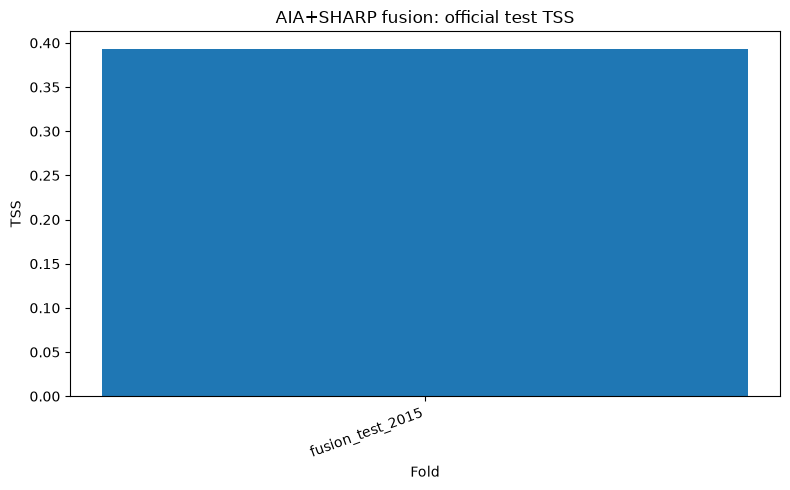

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_sharp24h_intermediate_fusion_cycle24_test_tss_by_fold.png


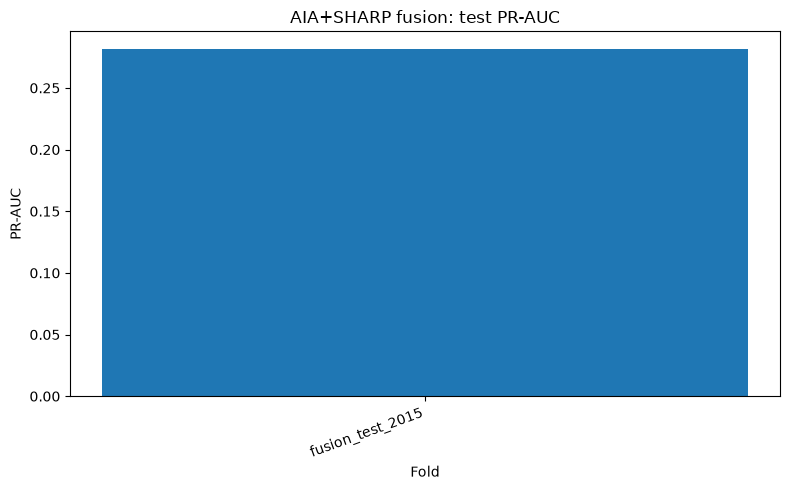

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_sharp24h_intermediate_fusion_cycle24_test_pr_auc_by_fold.png


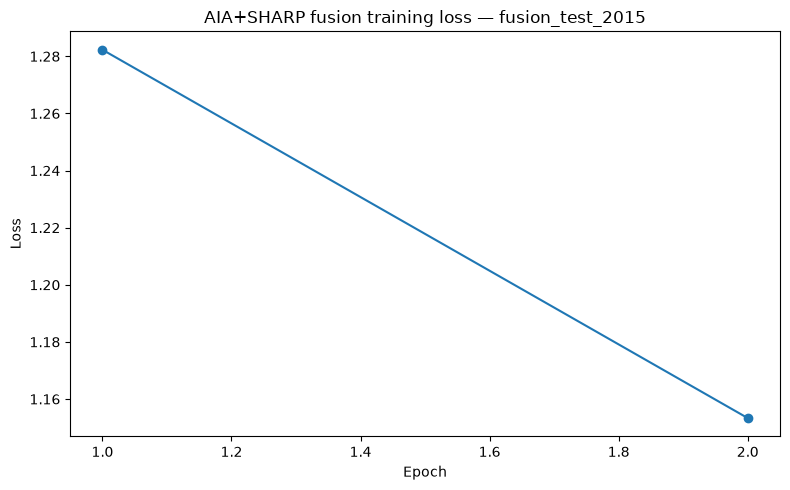

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_training_loss.png


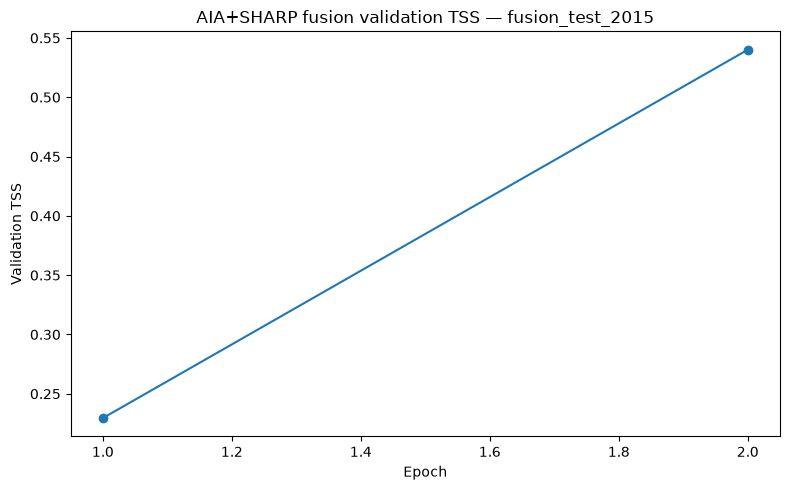

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_val_tss.png


In [16]:
import matplotlib.pyplot as plt

if not metrics_df.empty:
    fig = plt.figure(figsize=(8, 5))
    plt.bar(metrics_df["fold_id"], metrics_df["test_tss"])
    plt.title("AIA+SHARP fusion: official test TSS")
    plt.ylabel("TSS")
    plt.xlabel("Fold")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig_path = FIG_DIR / f"{FUSION_EXPERIMENT_NAME}_test_tss_by_fold.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

    fig = plt.figure(figsize=(8, 5))
    plt.bar(metrics_df["fold_id"], metrics_df["test_pr_auc"])
    plt.title("AIA+SHARP fusion: test PR-AUC")
    plt.ylabel("PR-AUC")
    plt.xlabel("Fold")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig_path = FIG_DIR / f"{FUSION_EXPERIMENT_NAME}_test_pr_auc_by_fold.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

if not history_all.empty:
    for fold_id, sub in history_all.groupby("fold_id"):
        fig = plt.figure(figsize=(8, 5))
        plt.plot(sub["epoch"], sub["train_loss"], marker="o", label="train loss")
        plt.title(f"AIA+SHARP fusion training loss — {fold_id}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.tight_layout()
        fig_path = FIG_DIR / f"{FUSION_EXPERIMENT_NAME}_{fold_id}_training_loss.png"
        plt.savefig(fig_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", fig_path)

        fig = plt.figure(figsize=(8, 5))
        plt.plot(sub["epoch"], sub["val_tss"], marker="o", label="val TSS")
        plt.title(f"AIA+SHARP fusion validation TSS — {fold_id}")
        plt.xlabel("Epoch")
        plt.ylabel("Validation TSS")
        plt.tight_layout()
        fig_path = FIG_DIR / f"{FUSION_EXPERIMENT_NAME}_{fold_id}_val_tss.png"
        plt.savefig(fig_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", fig_path)


## 12. Write protocol/results report

In [17]:
def fmt(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

mean_tss = metrics_df["test_tss"].mean() if "test_tss" in metrics_df.columns else np.nan
std_tss = metrics_df["test_tss"].std() if len(metrics_df) > 1 and "test_tss" in metrics_df.columns else np.nan
mean_auc = metrics_df["test_roc_auc"].mean() if "test_roc_auc" in metrics_df.columns else np.nan
mean_pr = metrics_df["test_pr_auc"].mean() if "test_pr_auc" in metrics_df.columns else np.nan

report = f"""
# AIA + SHARP Intermediate Fusion Training Results

**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Experiment

`{FUSION_EXPERIMENT_NAME}`

## Scope

This experiment is **Solar Cycle 24 only** and should be interpreted as within-cycle chronological/regime robustness.

## Modalities

- AIA: six-channel EUV image tensors.
- SHARP: 24h leakage-safe temporal magnetic aggregate vector.
- GOES: label-lineage only through `label_48h_final`; no GOES/XRS input features.

## Primary safety choices

- Embedded NPZ labels ignored.
- SHARP `history_count` excluded from the primary fusion feature vector: `{EXCLUDE_SHARP_HISTORY_COUNT}`.
- AIA preprocessing statistics estimated from training split only.
- SHARP imputer/scaler fitted on training split only.
- Threshold selected by validation TSS only.

## Folds completed

`{RUN_FOLDS}`

## Mean completed-fold performance

- Mean official test TSS: {fmt(mean_tss)}
- Std official test TSS: {fmt(std_tss)}
- Mean test ROC-AUC: {fmt(mean_auc)}
- Mean test PR-AUC: {fmt(mean_pr)}

## Notes

If only one fold was run, this is a sanity result and must not be reported as the final multimodal result. Run all three folds before paper-level comparison.

The 2014 fold remains the critical regime-stress fold.

## Outputs

- Summary: `results/metrics/{FUSION_EXPERIMENT_NAME}_run_summary.csv`
- Branch comparison: `results/metrics/{FUSION_EXPERIMENT_NAME}_branch_comparison_with_fusion.csv`
- Models: `results/models/{FUSION_EXPERIMENT_NAME}_*_best.pt`
- Predictions: `results/predictions/{FUSION_EXPERIMENT_NAME}_*_test_predictions.csv`
""".strip()

report_path = METRICS_DIR / f"{FUSION_EXPERIMENT_NAME}_report.md"
research_log_path = METRICS_DIR / f"{FUSION_EXPERIMENT_NAME}_research_log_update.md"
report_path.write_text(report, encoding="utf-8")
research_log_path.write_text(report, encoding="utf-8")

print(report)
print("\nSaved:", report_path)
print("Saved:", research_log_path)


# AIA + SHARP Intermediate Fusion Training Results

**Generated:** 2026-08-03 22:25:54

## Experiment

`aia_resnet18_sharp24h_intermediate_fusion_cycle24`

## Scope

This experiment is **Solar Cycle 24 only** and should be interpreted as within-cycle chronological/regime robustness.

## Modalities

- AIA: six-channel EUV image tensors.
- SHARP: 24h leakage-safe temporal magnetic aggregate vector.
- GOES: label-lineage only through `label_48h_final`; no GOES/XRS input features.

## Primary safety choices

- Embedded NPZ labels ignored.
- SHARP `history_count` excluded from the primary fusion feature vector: `True`.
- AIA preprocessing statistics estimated from training split only.
- SHARP imputer/scaler fitted on training split only.
- Threshold selected by validation TSS only.

## Folds completed

`['fusion_test_2015']`

## Mean completed-fold performance

- Mean official test TSS: 0.3934
- Std official test TSS: NA
- Mean test ROC-AUC: 0.8668
- Mean test PR-AUC: 0.2818

## Notes

If o

## 13. Final inventory

In [18]:
print("Generated metrics:")
for p in sorted(METRICS_DIR.glob(f"{FUSION_EXPERIMENT_NAME}*")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob(f"{FUSION_EXPERIMENT_NAME}*.png")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nGenerated models:")
for p in sorted(MODEL_DIR.glob(f"{FUSION_EXPERIMENT_NAME}*.pt")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024/1024:.1f} MiB)")

print("\nGenerated predictions:")
for p in sorted(PRED_DIR.glob(f"{FUSION_EXPERIMENT_NAME}*.csv")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nFinished:", datetime.now().isoformat(timespec="seconds"))


Generated metrics:
 - results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_branch_comparison_with_fusion.csv (1.7 KiB)
 - results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_metrics.json (1.0 KiB)
 - results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_threshold_grids.csv (98.4 KiB)
 - results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_training_history.csv (0.5 KiB)
 - results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_report.md (1.6 KiB)
 - results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_research_log_update.md (1.6 KiB)
 - results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_run_summary.csv (0.8 KiB)
 - results/metrics/aia_resnet18_sharp24h_intermediate_fusion_cycle24_training_history_all.csv (0.5 KiB)

Generated figures:
 - results/figures/aia_resnet18_sharp24h_intermediate_fusion_cycle24_fusion_test_2015_training_loss.png (52.6 KiB)
